## Load Dataset

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ishanshrivastava28/tata-online-retail-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'tata-online-retail-dataset' dataset.
Path to dataset files: /kaggle/input/tata-online-retail-dataset


In [6]:
import os

print(os.listdir(path))

['Online Retail Data Set.xlsx', 'Online Retail Data Set.csv']


## Data Exploration

In [7]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Customer Segmentation") \
    .getOrCreate()

file_path = path + "/Online Retail Data Set.csv"

df = spark.read.csv(file_path, header=True, inferSchema=True)

df.show(5)
df.printSchema()

+---------+---------+--------------------+--------+----------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|     InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+----------------+---------+----------+--------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|01-12-2010 08:26|     2.55|     17850|United Kingdom|
|   536365|    71053| WHITE METAL LANTERN|       6|01-12-2010 08:26|     3.39|     17850|United Kingdom|
|   536365|   84406B|CREAM CUPID HEART...|       8|01-12-2010 08:26|     2.75|     17850|United Kingdom|
|   536365|   84029G|KNITTED UNION FLA...|       6|01-12-2010 08:26|     3.39|     17850|United Kingdom|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|01-12-2010 08:26|     3.39|     17850|United Kingdom|
+---------+---------+--------------------+--------+----------------+---------+----------+--------------+
only showing top 5 rows
root
 |-- InvoiceNo: string (nu

In [8]:
df.count()

541909

In [9]:
df.select("Quantity", "UnitPrice").describe().show() #المكان خطأ

+-------+-----------------+-----------------+
|summary|         Quantity|        UnitPrice|
+-------+-----------------+-----------------+
|  count|           541909|           541909|
|   mean| 9.55224954743324|4.611113626082965|
| stddev|218.0811578502348|96.75985306117944|
|    min|           -80995|        -11062.06|
|    max|            80995|          38970.0|
+-------+-----------------+-----------------+



# Data Cleaning

In [10]:
df = df.dropna()
# remove the missing value

In [11]:
df.count()

406829

In [12]:
from pyspark.sql.functions import col
# remove negative and incorrect operations (returns)
df = df.filter(col("Quantity") > 0)
df = df.filter(col("UnitPrice") > 0)

In [13]:
quantiles = df.approxQuantile(
    "Quantity",
    [0.25, 0.75],
    0
)

Q1 = quantiles[0]
Q3 = quantiles[1]

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(lower, upper)
df = df.filter(
    (df.Quantity >= lower) &
    (df.Quantity <= upper)
)

-13.0 27.0


In [14]:
df=df.filter(df.UnitPrice>0)

In [15]:
df.select("Quantity", "UnitPrice").describe().show()

+-------+-----------------+------------------+
|summary|         Quantity|         UnitPrice|
+-------+-----------------+------------------+
|  count|           372237|            372237|
|   mean| 7.02998089926579|3.2285480594361573|
| stddev|6.661561738011441|22.814239960730774|
|    min|                1|             0.001|
|    max|               27|           8142.75|
+-------+-----------------+------------------+



In [16]:
from pyspark.sql.functions import to_timestamp
# date conversion
df = df.withColumn(
    "InvoiceDate",
    to_timestamp("InvoiceDate", "dd-MM-yyyy HH:mm")
)

In [17]:
from pyspark.sql.functions import year, month, dayofweek, hour

df = df.withColumn("year", year("InvoiceDate"))
df = df.withColumn("month", month("InvoiceDate"))
df = df.withColumn("day", dayofweek("InvoiceDate"))
df = df.withColumn("hour", hour("InvoiceDate"))

In [18]:
df = df.withColumn("TotalPrice", col("Quantity") * col("UnitPrice"))
#add TotalPrice feature

In [19]:
df = df.withColumn("CustomerID", col("CustomerID").cast("string")) #data tye conversion

In [20]:
df.printSchema()

root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day: integer (nullable = true)
 |-- hour: integer (nullable = true)
 |-- TotalPrice: double (nullable = true)



# Descriptive+ Diagnostic



In [102]:
df.selectExpr(
    "count(*) as total_rows",
    "count(distinct CustomerID) as customers",
    "count(distinct InvoiceNo) as invoices",
    "count(distinct StockCode) as products"
).show() #Number of orders, customers, and products

+----------+---------+--------+--------+
|total_rows|customers|invoices|products|
+----------+---------+--------+--------+
|    372237|     4238|   17312|    3647|
+----------+---------+--------+--------+



We learned that there are repeat customers.

In [103]:
df.selectExpr("sum(TotalPrice) as Total_Revenue").show() #Total revenues

+-----------------+
|    Total_Revenue|
+-----------------+
|5349223.243999537|
+-----------------+



In [104]:
df.groupBy("month").sum("TotalPrice").orderBy("month").show() #Sales by month

+-----+------------------+
|month|   sum(TotalPrice)|
+-----+------------------+
|    1| 297379.8700000096|
|    2| 278613.2500000069|
|    3|373387.16000002075|
|    4| 311241.4510000057|
|    5|425539.55000000447|
|    6|367954.47000000515|
|    7|354690.38100000675|
|    8|375410.94999999745|
|    9| 570915.7220000216|
|   10| 649636.5700000244|
|   11| 776758.9600000036|
|   12| 567694.9100000121|
+-----+------------------+



There are seasons, especially at the end of the year.

In [105]:
df.groupBy("CustomerID") \
  .sum("TotalPrice") \
  .orderBy("sum(TotalPrice)", ascending=False) \
  .show(10) #Best Customers

+----------+------------------+
|CustomerID|   sum(TotalPrice)|
+----------+------------------+
|     14911|114305.70000000013|
|     14096| 61295.61999999966|
|     13089|43423.030000000115|
|     17841| 39264.81000000023|
|     14088|          27597.28|
|     14298|27322.079999999954|
|     14156| 26971.25999999997|
|     12748| 26279.22000000007|
|     14646|          25623.12|
|     15311| 20737.80999999999|
+----------+------------------+
only showing top 10 rows


There are customers who spend a lot

In [106]:
df.groupBy("CustomerID") \
  .count() \
  .orderBy("count", ascending=False) \
  .show() #Order distribution to each customer: Who buys the most?

+----------+-----+
|CustomerID|count|
+----------+-----+
|     17841| 7802|
|     14911| 5272|
|     14096| 5072|
|     12748| 4465|
|     14606| 2683|
|     15311| 2037|
|     13263| 1666|
|     13089| 1652|
|     15039| 1488|
|     18118| 1275|
|     14159| 1198|
|     16033| 1137|
|     14796| 1130|
|     15005| 1114|
|     14056| 1102|
|     14769| 1069|
|     14298| 1047|
|     16549|  980|
|     14156|  976|
|     14527|  969|
+----------+-----+
only showing top 20 rows


In [107]:
df.groupBy("Country") \
  .sum("TotalPrice") \
  .orderBy("sum(TotalPrice)", ascending=False) \
  .show() #Sales by country

+---------------+------------------+
|        Country|   sum(TotalPrice)|
+---------------+------------------+
| United Kingdom| 4473584.123999097|
|        Germany|185419.52000000016|
|         France|168341.53000000014|
|           EIRE| 145090.6299999997|
|          Spain| 43928.71000000014|
|    Switzerland| 41193.46000000002|
|        Belgium|37682.200000000026|
|    Netherlands|30293.200000000004|
|       Portugal| 29412.68999999996|
|         Norway|26842.059999999983|
|      Australia|18288.590000000015|
|      Singapore|          18125.83|
|Channel Islands|16386.729999999996|
|          Italy|16308.619999999992|
|        Finland|16290.260000000002|
|         Cyprus| 11465.57999999999|
|        Denmark|10319.329999999998|
|        Austria| 9221.939999999995|
|         Sweden| 7392.490000000002|
|         Poland| 6655.029999999999|
+---------------+------------------+
only showing top 20 rows


The main market in the UK

In [108]:
from pyspark.sql.functions import sum, avg

df.groupBy("InvoiceNo") \
  .agg(sum("TotalPrice").alias("InvoiceTotalPrice")) \
  .select(avg("InvoiceTotalPrice").alias("avg_order_value")) \
  .show() #Average order value

+------------------+
|   avg_order_value|
+------------------+
|308.98932786506424|
+------------------+



Temporal analysis

In [109]:
from pyspark.sql import functions as F

# (Time Features)
df_time = df.withColumn("InvoiceDate", F.to_timestamp("InvoiceDate", "dd-MM-yyyy HH:mm")) \
            .withColumn("Year", F.year("InvoiceDate")) \
            .withColumn("Month", F.month("InvoiceDate")) \
            .withColumn("Hour", F.hour("InvoiceDate")) \
            .withColumn("TotalSales", F.col("Quantity") * F.col("UnitPrice"))

#Total annual sales
df_time.groupBy("Year").sum("TotalSales").show()

#(Drill-down to Month)
df_time.groupBy("Year", "Month").sum("TotalSales").orderBy("Year", "Month").show()

#(Drill-down to Hour)
peak_hours = df_time.groupBy("Hour").agg(
    F.sum("TotalSales").alias("Hourly_Revenue"),
    F.avg("TotalSales").alias("Avg_Order_Value")
).orderBy(F.desc("Hourly_Revenue"))

peak_hours.show()

+----+-----------------+
|Year|  sum(TotalSales)|
+----+-----------------+
|2010|356551.6200000136|
|2011|4992671.623999506|
+----+-----------------+

+----+-----+------------------+
|Year|Month|   sum(TotalSales)|
+----+-----+------------------+
|2010|   12| 356551.6200000136|
|2011|    1| 297379.8700000096|
|2011|    2| 278613.2500000069|
|2011|    3|373387.16000002075|
|2011|    4| 311241.4510000057|
|2011|    5|425539.55000000447|
|2011|    6|367954.47000000515|
|2011|    7|354690.38100000675|
|2011|    8|375410.94999999745|
|2011|    9| 570915.7220000216|
|2011|   10| 649636.5700000244|
|2011|   11| 776758.9600000036|
|2011|   12|211143.28999999855|
+----+-----+------------------+

+----+------------------+------------------+
|Hour|    Hourly_Revenue|   Avg_Order_Value|
+----+------------------+------------------+
|  12| 878464.2300000573| 12.91498301945129|
|  13| 803374.3700000345|13.234072481674236|
|  14| 693490.1110000219|13.500956099365766|
|  10| 641097.3210000028|18.780680

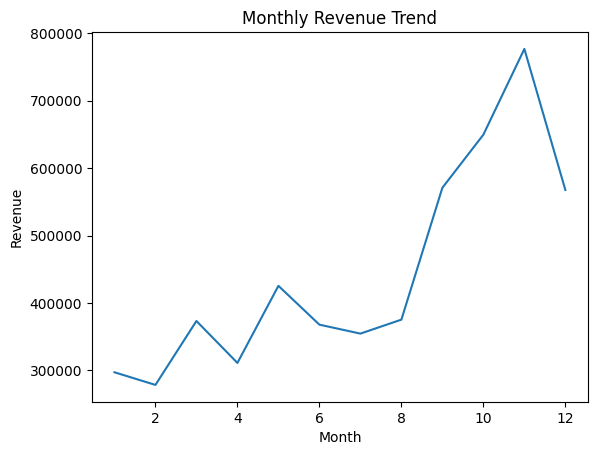

In [110]:
import matplotlib.pyplot as plt

monthly_pd = df.groupBy("month").sum("TotalPrice").orderBy("month").toPandas()

plt.figure()
plt.plot(monthly_pd["month"], monthly_pd["sum(TotalPrice)"])
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.savefig('Monthly Revenue Trend')
plt.show()

Peak sales: September – November

Marketing campaigns prior to this period

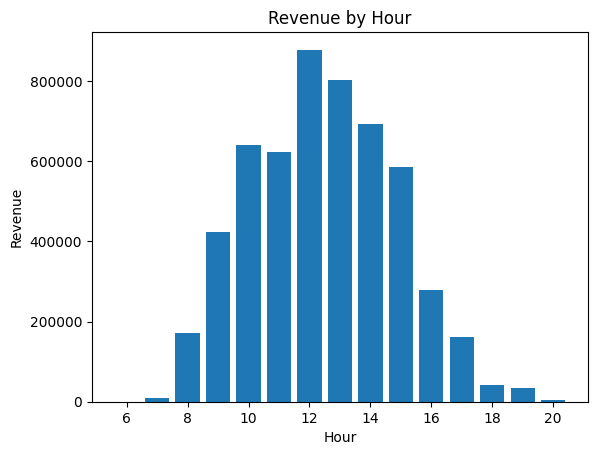

In [111]:
import matplotlib.pyplot as plt
peak_pd = peak_hours.toPandas()

plt.figure()
plt.bar(peak_pd["Hour"], peak_pd["Hourly_Revenue"])
plt.title("Revenue by Hour")
plt.xlabel("Hour")
plt.ylabel("Revenue")
plt.savefig('Revenue by Hour')
plt.show()

Best time: 10 – 14
Offers launch during these hours

Analysis of countries

In [112]:
df.selectExpr("sum(TotalPrice) as Total_Revenue").show()

+-----------------+
|    Total_Revenue|
+-----------------+
|5349223.243999537|
+-----------------+



In [113]:
# Identifying the top-selling countries in terms of revenue
top_countries = df_time.groupBy("Country").agg(F.sum("TotalSales").alias("CountryRevenue")) \
                       .orderBy(F.desc("CountryRevenue"))

top_countries.show(5)
#Drill-down to the top country
top_country_name = top_countries.first()["Country"]

df_time.filter(F.col("Country") == top_country_name) \
       .groupBy("Description").agg(F.sum("Quantity").alias("Units_Sold")) \
       .orderBy(F.desc("Units_Sold")).show(10)

+--------------+------------------+
|       Country|    CountryRevenue|
+--------------+------------------+
|United Kingdom| 4473584.123999097|
|       Germany|185419.52000000016|
|        France|168341.53000000014|
|          EIRE| 145090.6299999997|
|         Spain| 43928.71000000014|
+--------------+------------------+
only showing top 5 rows
+--------------------+----------+
|         Description|Units_Sold|
+--------------------+----------+
|ASSORTED COLOUR B...|     13094|
|PACK OF 72 RETROS...|     11605|
|JUMBO BAG RED RET...|     10740|
|WHITE HANGING HEA...|     10172|
|LUNCH BAG RED RET...|      8214|
|60 TEATIME FAIRY ...|      7305|
|VICTORIAN GLASS H...|      7258|
|PACK OF 60 PINK P...|      7189|
|JAM MAKING SET PR...|      6930|
|LUNCH BAG  BLACK ...|      6906|
+--------------------+----------+
only showing top 10 rows


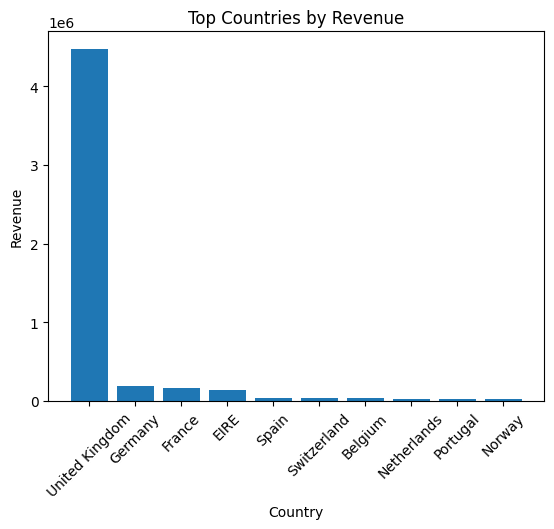

In [114]:
import matplotlib.pyplot as plt

top_countries_pd = top_countries.limit(10).toPandas()

plt.figure()
plt.bar(top_countries_pd["Country"], top_countries_pd["CountryRevenue"])
plt.xticks(rotation=45)
plt.title("Top Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.savefig('Top Countries by Revenue')
plt.show()

In [115]:
from pyspark.sql import functions as F
#Sales by country
df.groupBy("Country").agg(
    F.count("InvoiceNo").alias("Total_Transactions"),
    F.sum("Quantity").alias("Total_Quantity")
).orderBy(F.desc("Total_Quantity")).show()

+---------------+------------------+--------------+
|        Country|Total_Transactions|Total_Quantity|
+---------------+------------------+--------------+
| United Kingdom|            334073|       2238924|
|        Germany|              8517|         87536|
|         France|              7842|         78287|
|           EIRE|              6399|         61804|
|          Spain|              2378|         19372|
|    Switzerland|              1648|         18844|
|        Belgium|              1954|         18535|
|       Portugal|              1380|         12390|
|         Norway|               913|          9952|
|    Netherlands|               787|          8503|
|Channel Islands|               717|          6932|
|          Italy|               736|          6618|
|        Finland|               621|          6272|
|      Australia|               578|          5763|
|        Denmark|               325|          4668|
|         Cyprus|               581|          3849|
|        Aus

In [116]:
from pyspark.sql import functions as F

# Combine the two analyses into one table
country_analysis = df.groupBy("Country").agg(
    F.countDistinct("InvoiceNo").alias("Total_Transactions"),
    F.sum("Quantity").alias("Total_Units"),
    F.sum(F.col("Quantity") * F.col("UnitPrice")).alias("Total_Revenue")
)

# Calculating the Average Order Value
# And calculating the average price per unit sold
country_analysis = country_analysis.withColumn("Avg_Order_Value", F.col("Total_Revenue") / F.col("Total_Transactions")) \
                                   .withColumn("Avg_Unit_Price", F.col("Total_Revenue") / F.col("Total_Units"))

country_analysis.orderBy(F.desc("Avg_Order_Value")).show()

+--------------------+------------------+-----------+------------------+------------------+------------------+
|             Country|Total_Transactions|Total_Units|     Total_Revenue|   Avg_Order_Value|    Avg_Unit_Price|
+--------------------+------------------+-----------+------------------+------------------+------------------+
|           Singapore|                 7|       2127|          18125.83| 2589.404285714286| 8.521781852374238|
|             Lebanon|                 1|        386|1693.8800000000003|1693.8800000000003| 4.388290155440416|
|              Brazil|                 1|        356|1143.6000000000001|1143.6000000000001| 3.212359550561798|
|                 RSA|                 1|        351|1002.3099999999998|1002.3099999999998| 2.855584045584045|
|              Israel|                 5|       2546| 5000.330000000001|1000.0660000000001|1.9639945011783193|
|              Greece|                 5|       1429|           4573.32|           914.664|  3.20036389083275|
|

Main Market UK dominates revenue as its largest source of income
Focus on Improving the customer experience there
High-value markets: Netherlands Singapore
Very high Average Order Value
Targeting premium customers

The analysis of country-level performance revealed significant differences in purchasing behavior. Countries such as Singapore and the Netherlands demonstrated high average order values, indicating premium customer segments. In contrast, countries like Spain and the USA showed higher transaction volumes but lower average order values, suggesting opportunities for upselling strategies. These insights highlight the importance of region-specific marketing and pricing strateg

In [117]:
correlation_value = df.stat.corr("UnitPrice", "Quantity")
print("Correlation:", correlation_value)

Correlation: -0.05478523817002858


Price doesn't greatly affect demand; we can raise prices without significant losses.

# cohort Analysis

In [61]:
from pyspark.sql.functions import min, date_format

first_purchase = df.groupBy("CustomerID").agg(
    min("InvoiceDate").alias("FirstPurchaseDate")
)

first_purchase = first_purchase.withColumn(
    "CohortMonth",
    date_format("FirstPurchaseDate", "yyyy-MM")
)
#first purchase for each customer

In [62]:
df_cohort = df.join(first_purchase, on="CustomerID")

In [63]:
from pyspark.sql.functions import date_format

df_cohort = df_cohort.withColumn(
    "InvoiceMonth",
    date_format("InvoiceDate", "yyyy-MM")
)

In [64]:
from pyspark.sql.functions import months_between, col

df_cohort = df_cohort.withColumn(
    "CohortIndex",
    months_between(col("InvoiceDate"), col("FirstPurchaseDate")).cast("int")
)
#the diff in monthe between each purchase

In [65]:
cohort_data = df_cohort.groupBy("CohortMonth", "CohortIndex") \
    .agg({"CustomerID": "count"}) \
    .withColumnRenamed("count(CustomerID)", "NumCustomers")

In [66]:
cohort_pivot = cohort_data.groupBy("CohortMonth") \
    .pivot("CohortIndex") \
    .sum("NumCustomers") \
    .orderBy("CohortMonth")

cohort_pivot.show()

+-----------+-----+----+----+-----+----+-----+----+-----+-----+-----+-----+-----+----+
|CohortMonth|    0|   1|   2|    3|   4|    5|   6|    7|    8|    9|   10|   11|  12|
+-----------+-----+----+----+-----+----+-----+----+-----+-----+-----+-----+-----+----+
|    2010-12|25941|9220|7884|10765|8788|10809|9939|10198|10814|12100|13180|20400|3009|
|    2011-01|11672|2540|2732| 2934|2911| 2883|2755| 3424| 4016| 5226| 4386|  166|NULL|
|    2011-02| 8926|2020|1998| 2378|1774| 2093|2275| 2329| 3327| 1809|   32| NULL|NULL|
|    2011-03|11758|1657|2387| 2368|2094| 2187|3190| 3477| 3162|  171| NULL| NULL|NULL|
|    2011-04| 7351|1714| 865| 1417|1176| 1884|2339| 1532|  205| NULL| NULL| NULL|NULL|
|    2011-05| 6251| 989| 935| 1093|2074| 1614|2002|   43| NULL| NULL| NULL| NULL|NULL|
|    2011-06| 5867| 747| 967| 1496|2010| 1988|  85| NULL| NULL| NULL| NULL| NULL|NULL|
|    2011-07| 5291| 811|1403| 1585|1506| NULL|NULL| NULL| NULL| NULL| NULL| NULL|NULL|
|    2011-08| 5731|2374|3391| 1193|  18| NU

In [67]:
from pyspark.sql.functions import col

# Get all column names except 'CohortMonth'
customer_count_cols = [c for c in cohort_pivot.columns if c != "CohortMonth"]

# Create a list of expressions for retention rate calculation
# Divide each month's customer count by the initial count (from month 0) for that cohort
retention_expressions = [
    (col(c) / col("0")).alias(c)
    for c in customer_count_cols
]

# Add 'CohortMonth' back to the selection
retention_expressions.insert(0, col("CohortMonth"))

# Apply the expressions to create the retention DataFrame
cohort_retention = cohort_pivot.select(*retention_expressions)

cohort_retention.show()

+-----------+---+-------------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+-------------------+
|CohortMonth|  0|                  1|                   2|                   3|                   4|                  5|                   6|                   7|                  8|                   9|                  10|                  11|                 12|
+-----------+---+-------------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+-------------------+
|    2010-12|1.0|0.35542191896997033|    0.30392043483289|  0.4149801472572376|  0.3387687444585791| 0.4166763039204348| 0.38313866080721637| 0.39312285571103656|0.41686904899579813|  0.4664430823792452

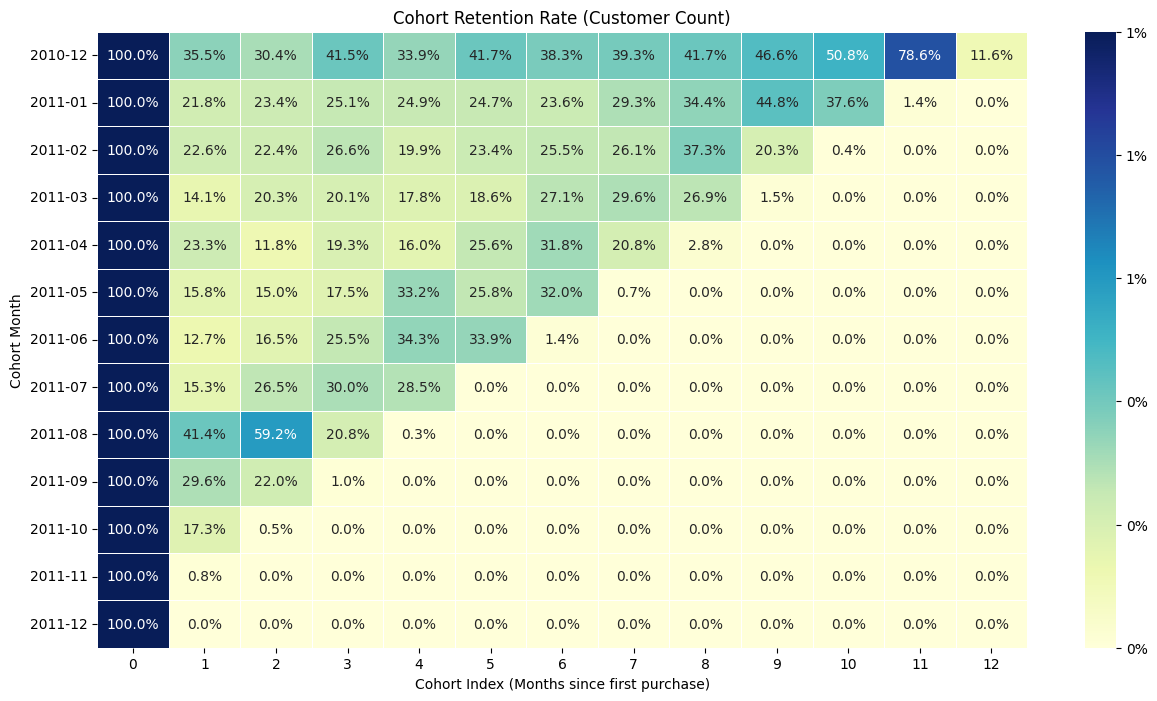

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert to Pandas DataFrame for visualization
cohort_retention_pd = cohort_retention.toPandas()

# Set 'CohortMonth' as index and clean up column names
cohort_retention_pd = cohort_retention_pd.set_index('CohortMonth')
cohort_retention_pd.columns = cohort_retention_pd.columns.astype(int)

# Fill NaN values with 0 for visualization (or another appropriate value)
cohort_retention_pd = cohort_retention_pd.fillna(0)

# Create the heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(
    cohort_retention_pd,
    annot=True,
    fmt=".1%", # Format annotations as percentages
    cmap="YlGnBu",
    linewidths=.5,
    cbar_kws={'format': '%.0f%%'} # Format color bar as percentages
)
plt.title('Cohort Retention Rate (Customer Count)')
plt.xlabel('Cohort Index (Months since first purchase)')
plt.ylabel('Cohort Month')
plt.show()

# **RFM** **Analysis** (recency frequency, Monetary)

In [69]:
from pyspark.sql.functions import max
#Last date” in the data to calculate Recency
max_date = df.select(max("InvoiceDate")).collect()[0][0]
print(max_date)

2011-12-09 12:50:00


In [70]:
from pyspark.sql.functions import count, sum, datediff, lit

rfm = df.groupBy("CustomerID").agg(
    datediff(lit(max_date), max("InvoiceDate")).alias("Recency"),
    count("InvoiceNo").alias("Frequency"),
    sum("TotalPrice").alias("Monetary")
)

rfm.show()

+----------+-------+---------+------------------+
|CustomerID|Recency|Frequency|          Monetary|
+----------+-------+---------+------------------+
|     16250|    261|       24|389.44000000000005|
|     15574|    177|      166|            672.01|
|     15555|     12|      892| 4737.549999999994|
|     15271|      7|      274|2507.0699999999997|
|     17714|    320|       10|             153.0|
|     17686|      7|      283| 5600.980000000005|
|     13865|     58|       30|501.56000000000006|
|     14157|     19|       47| 412.7200000000001|
|     13610|     12|      226|1131.8799999999999|
|     13772|     33|      177|           1132.13|
|     13282|     18|       37|1132.1399999999999|
|     12394|     63|       22| 543.0799999999999|
|     16320|    172|       55|1016.1400000000001|
|     13192|     95|       63|            911.94|
|     17757|      1|      732|            4975.5|
|     17551|    359|       43|            306.84|
|     13187|    337|       37|236.01999999999995|


In [71]:
rfm.count()

4238

In [72]:
df_rfm = rfm.select("Frequency", "Monetary")
df_rfm.corr("Frequency", "Monetary")

0.7806332774663208

In [ ]:

cols = ["Recency", "Frequency", "Monetary"]

for col_name in cols:

    quants = rfm.approxQuantile(col_name, [0.25, 0.75], 0.05)
    q1, q3 = quants[0], quants[1]

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr


    rfm = rfm.filter((rfm[col_name] >= lower_bound) & (rfm[col_name] <= upper_bound))



# **k-means**
K-Means clustering was applied on RFM features after scaling the data to ensure equal contribution of each variable. The model grouped customers into three distinct clusters representing different behavioral segments.

In [78]:
from pyspark.ml.feature import VectorAssembler, StandardScaler

assembler = VectorAssembler(
    inputCols=["Recency", "Frequency", "Monetary"],
    outputCol="features"
)

rfm_vec = assembler.transform(rfm)

scaler = StandardScaler(
    inputCol="features",
    outputCol="scaled_features"
)

scaler_model = scaler.fit(rfm_vec)
rfm_scaled = scaler_model.transform(rfm_vec)

In [79]:
from pyspark.ml.clustering import KMeans

kmeans = KMeans(k=3, featuresCol="scaled_features", seed=1)

model = kmeans.fit(rfm_scaled)

clusters = model.transform(rfm_scaled)

clusters.select("CustomerID", "prediction").show(30)

+----------+----------+
|CustomerID|prediction|
+----------+----------+
|     13865|         0|
|     14157|         0|
|     13282|         1|
|     12394|         0|
|     16320|         1|
|     13192|         1|
|     16639|         1|
|     17866|         2|
|     13107|         1|
|     17256|         2|
|     16027|         2|
|     13395|         2|
|     15041|         2|
|     17024|         0|
|     14552|         2|
|     12750|         2|
|     18211|         0|
|     12710|         1|
|     12816|         0|
|     17660|         2|
|     17584|         1|
|     16654|         2|
|     17917|         1|
|     17375|         2|
|     13655|         1|
|     15829|         2|
|     16185|         0|
|     14443|         1|
|     16031|         1|
|     17930|         0|
+----------+----------+
only showing top 30 rows


In [80]:
clusters.groupBy("prediction").avg("Recency", "Frequency", "Monetary").show()

+----------+------------------+------------------+------------------+
|prediction|      avg(Recency)|    avg(Frequency)|     avg(Monetary)|
+----------+------------------+------------------+------------------+
|         1|45.652054794520545| 61.77945205479452| 901.1899054794529|
|         2|156.11871227364185|22.124748490945674|327.53893360161015|
|         0| 41.08870967741935|21.258960573476703|325.39273476702476|
+----------+------------------+------------------+------------------+



Cluster 2: They haven't bought in a while- (At Risk) we can Retargeting

Cluster 1: Active- Very High Spend (VIP)

Cluster 0: Frequent Buyers (Regular)

In [ ]:
# Calculate the number of customers in each cluster 
clusters.groupBy("prediction").count().orderBy("prediction").show()

+----------+-----+
|prediction|count|
+----------+-----+
|         0| 1116|
|         1|  730|
|         2|  497|
+----------+-----+



Interpretation
The clustering results revealed three customer segments:
Low-value customers with low spending and high recency
High-value customers with significantly high monetary value
Frequent customers with high purchase frequency

In [85]:
from pyspark.ml.feature import PCA

# Initialize PCA with 2 components
pca = PCA(k=2, inputCol="scaled_features", outputCol="pca_features")

# Fit PCA model to the scaled data
pca_model = pca.fit(clusters)

# Transform the data to get the 2D PCA features
pca_result = pca_model.transform(clusters)

PCA visualization saved as 'customer_clusters_pca.png'


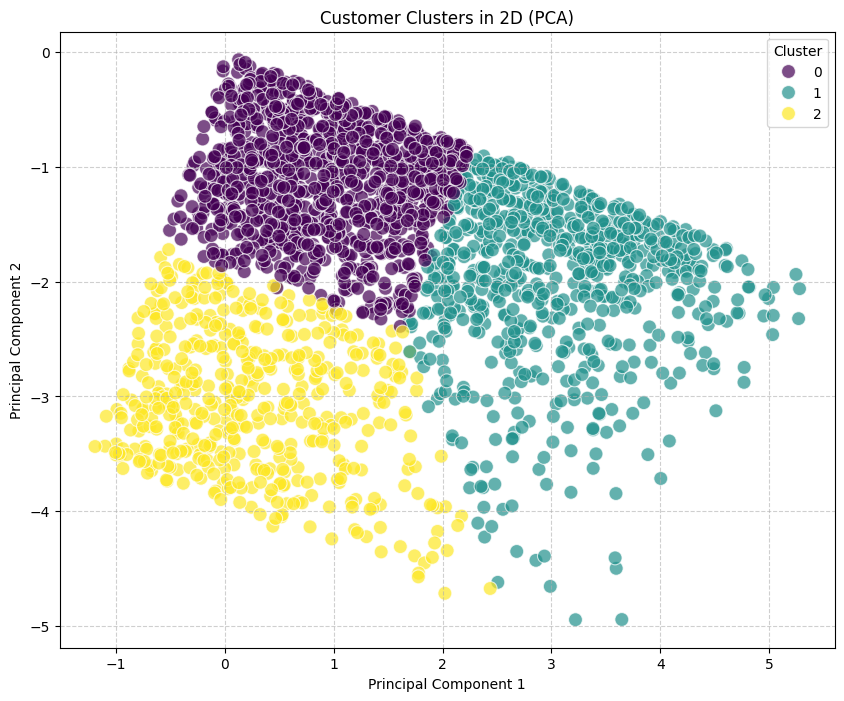

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract PCA features and predictions into a Pandas DataFrame
pca_df = pca_result.select("pca_features", "prediction").toPandas()

# Split the pca_features vector into two separate columns
pca_df['PCA1'] = pca_df['pca_features'].apply(lambda x: x[0])
pca_df['PCA2'] = pca_df['pca_features'].apply(lambda x: x[1])

# Plot the 2D PCA visualization of clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PCA1', y='PCA2', hue='prediction', data=pca_df, palette='viridis', s=100, alpha=0.7)
plt.title('Customer Clusters in 2D (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)


plt.savefig('customer_clusters_pca.png')

plt.show()

# predect

In [95]:
from pyspark.sql import functions as F

customer_features = df.groupBy("CustomerID").agg(
    F.sum("Quantity").alias("Total_Quantity"),
    F.avg("UnitPrice").alias("Avg_Price"),
    F.sum("TotalPrice").alias("Total_Spending"),
    F.count("InvoiceNo").alias("Num_Transactions")
)

In [96]:
threshold = customer_features.approxQuantile("Total_Spending", [0.8], 0.01)[0]

data = customer_features.withColumn(
    "label",
    (F.col("Total_Spending") >= threshold).cast("int")
)

In [97]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=["Total_Quantity", "Avg_Price", "Num_Transactions"],
    outputCol="features"
)

final_data = assembler.transform(data).select("features", "label")

In [98]:
from pyspark.ml.classification import DecisionTreeClassifier

train, test = final_data.randomSplit([0.8, 0.2], seed=42)

model = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="label"
).fit(train)

predictions = model.transform(test)

In [99]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    metricName="f1"
).evaluate(predictions)
print("Accuracy:", acc_eval.evaluate(predictions))
print("F1 Score:", f1)

Accuracy: 0.9434673366834171
F1 Score: 0.9427100614284473


### Confusion Matrix

/usr/local/lib/python3.12/dist-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


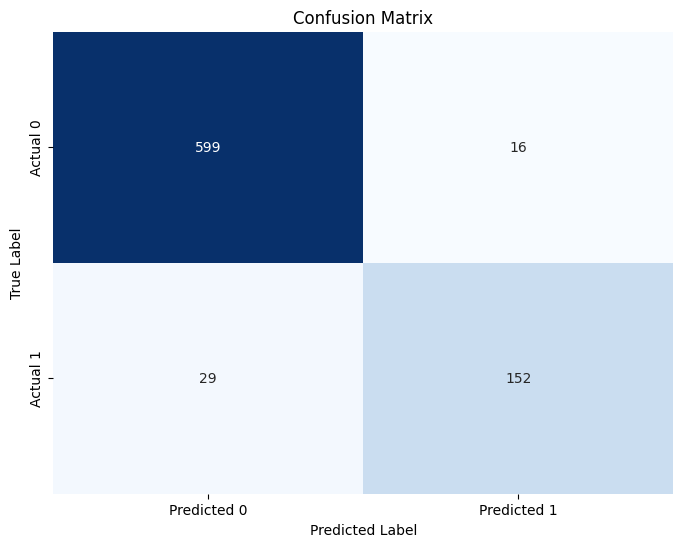

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.mllib.evaluation import MulticlassMetrics
import pandas as pd

# Prepare data for MulticlassMetrics
predictionAndLabels = predictions.select("prediction", "label").rdd.map(lambda row: (float(row.prediction), float(row.label)))

# Instantiate metrics object
metrics = MulticlassMetrics(predictionAndLabels)

# Get the confusion matrix as a PySpark Matrix object
confusion_matrix_mllib = metrics.confusionMatrix()

# Convert to a dense matrix, then to a NumPy array for Pandas/Seaborn
confusion_matrix_array = confusion_matrix_mllib.toArray()

# Convert to Pandas DataFrame for easier plotting with Seaborn
confusion_matrix_pd = pd.DataFrame(confusion_matrix_array, index=[0, 1], columns=[0, 1])

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_pd, annot=True, fmt="g", cmap="Blues", cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.savefig('Confusion Matrix.png')
plt.show()

### Feature Importance from Decision Tree Model

In [101]:
import pandas as pd

# Get feature importances from the trained model
feature_importances = model.featureImportances.toArray()

# Get feature names from the assembler
feature_names = assembler.getInputCols()

# Create a Pandas DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

display(feature_importance_df)

,Feature,Importance
0,Total_Quantity,0.877312
1,Avg_Price,0.098114
2,Num_Transactions,0.024574


In [ ]:
df.groupBy("Description") \
  .sum("TotalPrice") \
  .withColumnRenamed("sum(TotalPrice)", "Revenue") \
  .orderBy("Revenue", ascending=False) \
  .show(15)

+--------------------+------------------+
|         Description|           Revenue|
+--------------------+------------------+
|PAPER CRAFT , LIT...|          168469.6|
|REGENCY CAKESTAND...|142592.94999999966|
|WHITE HANGING HEA...|100448.14999999953|
|JUMBO BAG RED RET...| 85220.78000000044|
|MEDIUM CERAMIC TO...| 81416.72999999998|
|             POSTAGE| 77803.95999999999|
|       PARTY BUNTING| 68844.33000000006|
|ASSORTED COLOUR B...| 56580.34000000046|
|              Manual| 53779.93000000001|
|  RABBIT NIGHT LIGHT|51346.199999999975|
|       CHILLI LIGHTS| 46286.50999999995|
|PAPER CHAIN KIT 5...|  42660.8300000002|
|PICNIC BASKET WIC...|           39619.5|
|BLACK RECORD COVE...| 39064.55000000002|
|JUMBO BAG PINK PO...| 37289.58999999984|
+--------------------+------------------+
only showing top 15 rows
